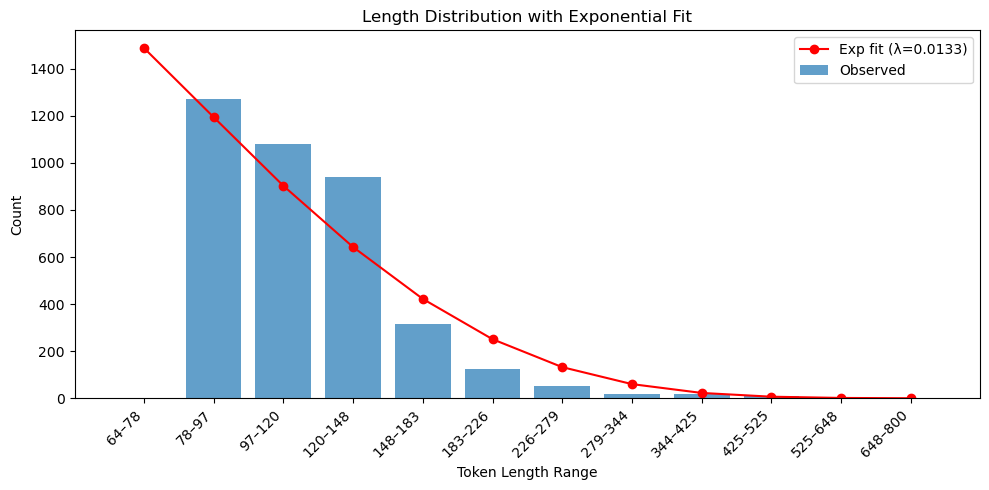

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Your observed bins and counts
bin_labels = [
    "64–78", "78–97", "97–120", "120–148", "148–183",
    "183–226", "226–279", "279–344", "344–425",
    "425–525", "525–648", "648–800"
]
counts = np.array([0, 1273, 1081, 939, 314, 124, 51, 20, 18, 10, 3, 3])

# Parse the ranges
lows = np.array([int(lbl.split('–')[0]) for lbl in bin_labels])
highs = np.array([int(lbl.split('–')[1]) for lbl in bin_labels])
mids = (lows + highs) / 2

# Total samples
N = counts.sum()

# Estimate lambda = 1 / sample mean (approximate mean by midpoint weighted)
sample_mean =  75
lam = 1 / sample_mean

# Compute expected count in each bin exactly:
#   P(low < X <= high) = exp(-λ·low) – exp(-λ·high)
probs = np.exp(-lam * mids)
expecteds = N * probs

# Plot
plt.figure(figsize=(10,5))

# 1) observed histogram
x = np.arange(len(bin_labels))
plt.bar(x, counts, label="Observed", alpha=0.7)

# 2) fitted exp “pdf” as red line at bin midpoints
plt.plot(x, expecteds, color='red', marker='o',
         linestyle='-', label=f"Exp fit (λ={lam:.4f})")

# Labels & legend
plt.xticks(x, bin_labels, rotation=45, ha='right')
plt.xlabel("Token Length Range")
plt.ylabel("Count")
plt.title("Length Distribution with Exponential Fit")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# FAILED GOODNESS OF FIT TEST
import numpy as np
from scipy.stats import chi2

# Observed data
# merge labels so that each count is at least 5
bin_labels = [
     "78–97", "97–120", "120–148", "148–183",
    "183–226", "226–279", "279–344", "344–425",
    "425–525", "525–800"
]
obs = np.array([ 1273, 1081, 939, 314, 124, 51, 20, 18, 10, 6])
N = obs.sum()

# Parse numeric bin edges
lows  = np.array([int(lbl.split('–')[0]) for lbl in bin_labels])
highs = np.array([int(lbl.split('–')[1]) for lbl in bin_labels])
mids  = (lows + highs) / 2

# Estimate lambda via sample mean
sample_mean = np.sum(mids * obs) / N
lam = 1 / sample_mean

# Compute expected counts under Exp(lam)
probs = np.exp(-lam * lows) - np.exp(-lam * highs)
exp_counts = N * probs
exp_counts *= N / exp_counts.sum()

mask = exp_counts > 0
obs_filt = obs[mask]
exp_filt = exp_counts[mask]

# Merge any very small expected bins (if <5) with neighbors to satisfy χ² assumptions
# For simplicity, here we’ll drop bins with exp<5 and combine them into the last bin:
mask = exp_counts >= 5
obs2 = np.append(obs[mask], obs[~mask].sum())
exp2 = np.append(exp_counts[mask], exp_counts[~mask].sum())

# 4) Compute χ² statistic by hand
chi2_stat = np.sum((obs - exp_counts)**2 / exp_counts)

# Degrees of freedom: #bins − 1 (for sum constraint) − 1 (for estimated λ)
df = len(obs) - 1 - 1

# 5) Compute p‐value from chi‐square distribution
p_value = chi2.sf(chi2_stat, df)

print(f"Estimated λ = {lam:.4f}")
print(f"χ² statistic = {chi2_stat:.2f}")
print(f"Degrees of freedom = {df}")
print(f"p‐value = {p_value:.8f}")

Estimated λ = 0.0082
χ² statistic = 2938.29
Degrees of freedom = 8
p‐value = 0.00000000


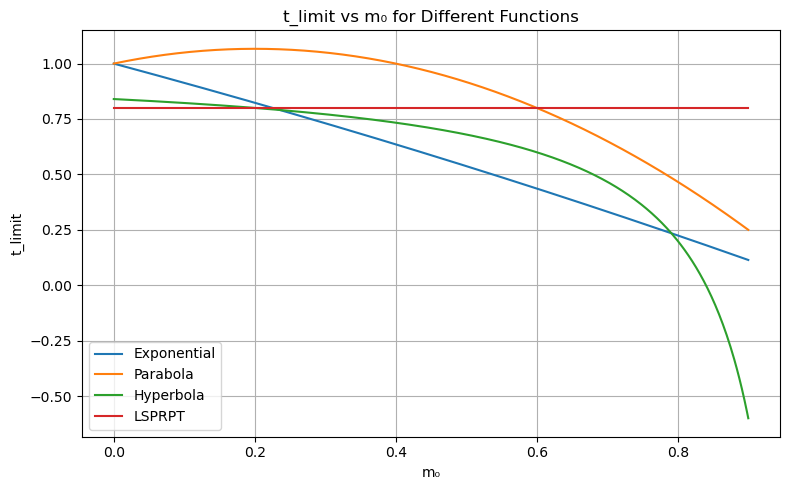

In [15]:
# TODO: draw the following graphs on the same set of axes
# m0 from 0 to 1 vs t_limit
# Exponential: t_limit =(1 - math.exp(-0.3 + 0.3 * m0)) / (1 - math.exp(-0.3))
# Parabola: t_limit = -0.4761904762 * m0 **2  -1.4761904762 * m0  + 1
# Hyperbola: t_limit = -0.16 / (m0 - 1) + 1
# LSPRPT: t_limit = 0.8

import numpy as np
import matplotlib.pyplot as plt

# Define m0 range from 0 to just before 1 to avoid the hyperbola singularity
m0 = np.linspace(0, 0.9, 500)

# Compute t_limit for each function
t_exp = (1 - np.exp(-0.3 + 0.3 * m0)) / (1 - np.exp(-0.3))
t_par = -5/3 * m0**2 +2/3 * m0 + 1
t_hyp = 0.16 / (m0 - 1) + 1
t_ls  = np.full_like(m0, 0.8)

# Plot all curves on the same axes
plt.figure(figsize=(8, 5))
plt.plot(m0, t_exp, label='Exponential')
plt.plot(m0, t_par, label='Parabola')
plt.plot(m0, t_hyp, label='Hyperbola')
plt.plot(m0, t_ls,  label='LSPRPT')

# Labels and styling
plt.xlabel('m₀')
plt.ylabel('t_limit')
plt.title('t_limit vs m₀ for Different Functions')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


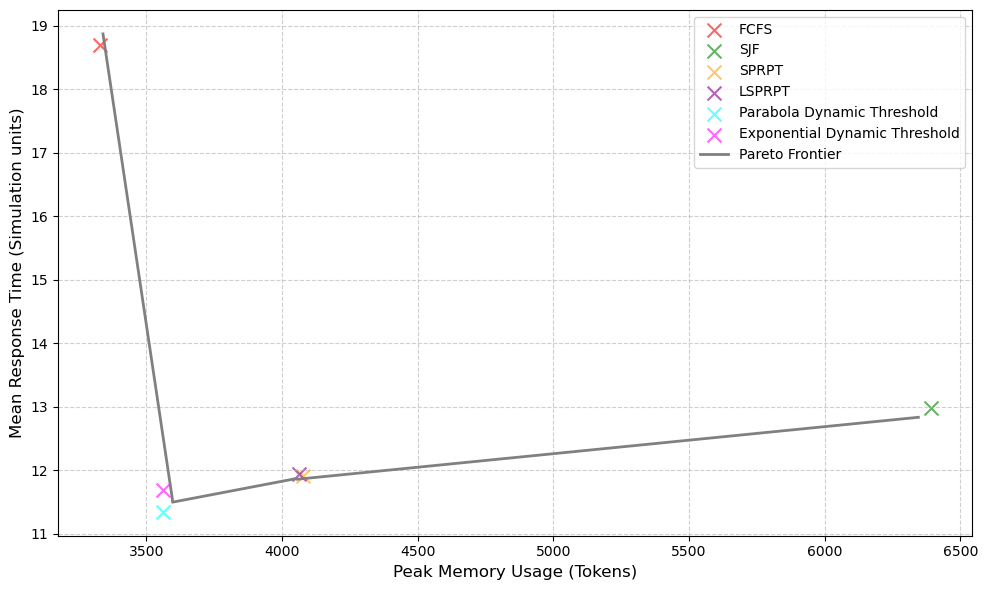

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Simulation metadata
# sim_time = 250000, arrival_rate = 0.6, token_gen_rate = 256, job_service_distribution = "exponential-exponential"

# Data
labels = ["FCFS", "SJF", "SPRPT", "LSPRPT", "Parabola Dynamic Threshold", "Exponential Dynamic Threshold"]
peak_memory = np.array([3340, 6345, 4054, 4054, 3596, 3596])
mean_response_time = np.array([18.875, 12.833, 11.869, 11.856, 11.535, 11.495])

# Define distinct colors for each policy
colors = {
    "FCFS": "red",
    "SJF": "green",
    "SPRPT": "orange",
    "LSPRPT": "purple",
    "Parabola Dynamic Threshold": "cyan",
    "Exponential Dynamic Threshold": "magenta"
}

# Add jitter to points
np.random.seed(42)  # For reproducibility
jitter_x = peak_memory + np.random.uniform(-50, 50, size=len(peak_memory))
jitter_y = mean_response_time + np.random.uniform(-0.2, 0.2, size=len(mean_response_time))

# Sort original data for Pareto curve
data = sorted(zip(peak_memory, mean_response_time), key=lambda x: x[0])
sorted_peak_memory = [x[0] for x in data]
sorted_mean_response_time = [x[1] for x in data]

# Construct Pareto frontier over all original points (minimizing y)
pareto_peak_memory = [sorted_peak_memory[0]]
pareto_mean_response_time = [sorted_mean_response_time[0]]

for i in range(1, len(sorted_peak_memory)):
    pareto_peak_memory.append(sorted_peak_memory[i])
    pareto_mean_response_time.append(sorted_mean_response_time[i])

# Plot
plt.figure(figsize=(10, 6))

# Plot jittered points with distinct colors
for x, y, label in zip(jitter_x, jitter_y, labels):
    plt.scatter(x, y, marker='x', color=colors[label], s=100, label=label, alpha=0.6)

# Draw Pareto frontier over original data
plt.plot(pareto_peak_memory, pareto_mean_response_time, linestyle='-', color='grey', linewidth=2, label='Pareto Frontier')

# Deduplicate legend entries
handles, legend_labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
plt.legend(unique.values(), unique.keys())

# Axis labels and title
plt.xlabel("Peak Memory Usage (Tokens)", fontsize=12)
plt.ylabel("Mean Response Time (Simulation units)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Average Waiting Time 

lamda = 0.4
token_gen_rate = [128, 256, 512]
avg_waiting_time = {
    "FCFS": [2.240, 2.251, 2.253],
    "SPRPT":[2.775, 2.794, 2.796],
    "LSRPT": [2.704, 2.726, 2.728],
    "DTPRPT(parabola)": [0, 0, 0],
    "DTPRPT(exponential)": [0, 0, 0],
    "DTPRPT(hyperbola)": [0, 0, 0],
}


lamda = 0.6
token_gen_rate = [128, 256, 512]
avg_waiting_time = {
    "FCFS": [16.635, 16.887, 16.935],
    "SPRPT":[10.767, 10.874, 10.899],
    "LSRPT": [10.753, 10.860, 10.884],
    "DTPRPT(parabola)": [10.483, 10.515, 10.556],
    "DTPRPT(exponential)": [10.494, 10.517, 10.561],
    "DTPRPT(hyperbola)": [0 ,0 , 0],
}


lamda = 0.8
token_gen_rate = [128, 256, 512]
avg_waiting_time = {
    "FCFS": [2988.356, 3008.384, 3015.300],
    "SPRPT":[1628.542, 1642.917, 1648.391],
    "LSRPT": [1628.528, 1642.904, 1648.377],
    "DTPRPT(parabola)": [1628.468, 0, 0],
    "DTPRPT(exponential)": [1628.475, 0, 0],
    "DTPRPT(hyperbola)": [0, 0, 0],
}


In [117]:
def plot_three_subfigures(data_triples, xlabel, ylabel, suptitle=None, figsize=(15,5)):
    """
    data_triples: list of tuples (lamda, token_gen_rate, mean_response_time_dict)
        where mean_response_time_dict maps algorithm name -> list of response times
    xlabel:  label for the x-axis
    ylabel:  label for the y-axis
    suptitle: optional overall title for the figure
    figsize: size of the entire figure
    """
    # Determine consistent colors from the first subplot's algorithms
    first_algos = list(data_triples[0][2].keys())
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_map = {
        algo: default_colors[i % len(default_colors)]
        for i, algo in enumerate(first_algos)
    }
    
    # create figure and axes without shared y-axis
    fig, axes = plt.subplots(1, len(data_triples), figsize=figsize, sharey=False)
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    
    # collect one handle per algorithm for the legend
    handles, labels = [], []
    
    for ax, (lamda, token_rates, mrt_dict) in zip(axes, data_triples):
        for algo_name, times in mrt_dict.items():
            # use the predefined color for this algorithm
            h, = ax.plot(token_rates, times, marker='o',
                         label=algo_name, color=color_map.get(algo_name, 'black'), alpha=0.5)
            if algo_name not in labels:
                handles.append(h)
                labels.append(algo_name)
        
        ax.set_title(f"λ = {lamda}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.5)
    
    # one legend for all, below the plots
    fig.legend(handles, labels,
               loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


def plot_single_lambda(data_triples, lambda_value, xlabel, ylabel, suptitle=None, figsize=(6,5)):
    """
    Plots a single subplot for the specified lambda value from the data_triples.
    
    Parameters
    ----------
    data_triples : list
        Each tuple is (lamda, token_gen_rate_list, algorithm_results_dict)
    lambda_value : float
        The lambda value to plot (e.g., 0.4, 0.6, or 0.8)
    xlabel : str
        Label for the x-axis
    ylabel : str
        Label for the y-axis
    suptitle : str, optional
        Title for the figure
    figsize : tuple, optional
        Size of the entire figure
    """
    # Find the matching data triple
    matching = [t for t in data_triples if t[0] == lambda_value]
    if not matching:
        raise ValueError(f"No data found for lambda = {lambda_value}")
    
    lamda, token_rates, mrt_dict = matching[0]
    
    sorted_algos = sorted(mrt_dict.keys())
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_map = {
        algo: default_colors[i % len(default_colors)]
        for i, algo in enumerate(sorted_algos)
    }
    
    fig, ax = plt.subplots(figsize=figsize)
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    
    handles, labels = [], []
    for algo in sorted_algos:
        times = mrt_dict[algo]
        h, = ax.plot(token_rates, times, marker='o', label=algo,
                     color=color_map.get(algo, 'black'), alpha=0.5)
        handles.append(h)
        labels.append(algo)
    
    ax.set_title(f"λ = {lamda}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.15))
    
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

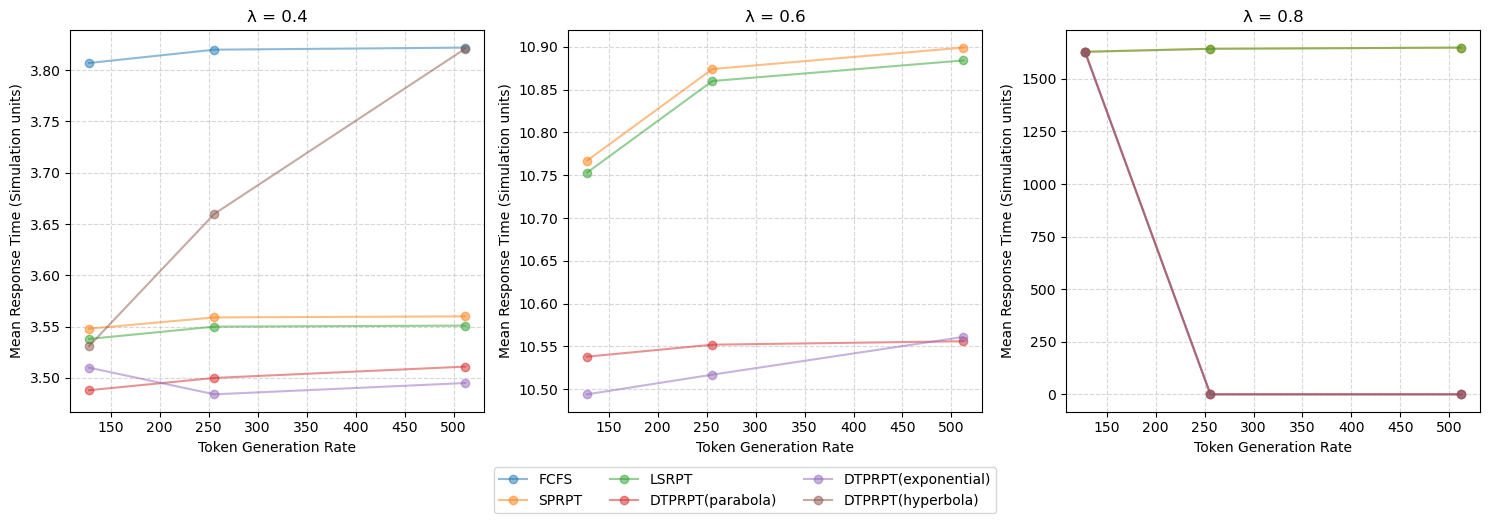

In [101]:

mean_response_time_triples = [
    (0.4,
        [128, 256, 512],
        {
            "FCFS": [3.807, 3.820, 3.822],
            "SPRPT":[3.548, 3.559, 3.560],
            "LSRPT":[3.538, 3.550, 3.551],
            "DTPRPT(parabola)":[3.488, 3.500, 3.511],
            "DTPRPT(exponential)":[3.510, 3.484, 3.495],
            "DTPRPT(hyperbola)":[3.531, 3.660, 3.821],
        }),
    (0.6,
        [128, 256, 512],
        {
            # "FCFS": [16.635,16.887,16.935],
            "SPRPT":[10.767,10.874,10.899],
            "LSRPT":[10.753,10.860,10.884],
            "DTPRPT(parabola)":[10.538,10.552,10.556],
            "DTPRPT(exponential)":[10.494,10.517,10.561],
            # "DTPRPT(hyperbola)":[12.888,17.827,19.483],
        }),
    (0.8,
        [128, 256, 512],
        {
            # "FCFS":[2988.356,3008.384,3015.300],
            "SPRPT":[1628.542,1642.917,1648.391],
            "LSRPT":[1628.528,1642.904,1648.377],
            "DTPRPT(parabola)":[1628.511,   0,     0     ],
            "DTPRPT(exponential)":[1628.475, 0,     0     ],
            "DTPRPT(hyperbola)":[1628.537, 0,     0     ],
        }),
]

plot_one_subfigure(
    mean_response_time_triples,
    xlabel="Token Generation Rate",
    ylabel="Mean Response Time (Simulation units)"
)

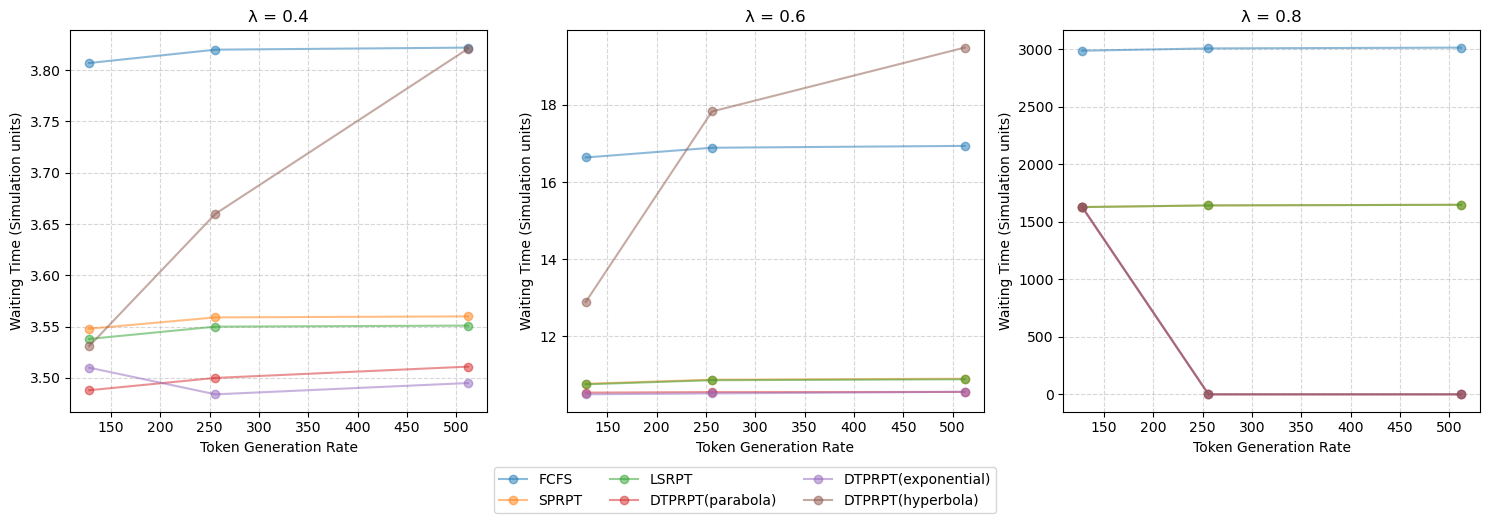

In [103]:

waiting_time_triples = [
    (0.4,
        [128, 256, 512],
        {
            "FCFS": [3.807, 3.820, 3.822],
            "SPRPT":[3.548, 3.559, 3.560],
            "LSRPT":[3.538, 3.550, 3.551],
            "DTPRPT(parabola)":[3.488, 3.500, 3.511],
            "DTPRPT(exponential)":[3.510, 3.484, 3.495],
            "DTPRPT(hyperbola)":[3.531, 3.660, 3.821],
        }),
    (0.6,
        [128, 256, 512],
        {
            "FCFS": [16.635,16.887,16.935],
            "SPRPT":[10.767,10.874,10.899],
            "LSRPT":[10.753,10.860,10.884],
            "DTPRPT(parabola)":[10.538,10.552,10.556],
            "DTPRPT(exponential)":[10.494,10.517,10.561],
            "DTPRPT(hyperbola)":[12.888,17.827,19.483],
        }),
    (0.8,
        [128, 256, 512],
        {
            "FCFS":[2988.356,3008.384,3015.300],
            "SPRPT":[1628.542,1642.917,1648.391],
            "LSRPT":[1628.528,1642.904,1648.377],
            "DTPRPT(parabola)":[1628.511,   0,     0     ],
            "DTPRPT(exponential)":[1628.475, 0,     0     ],
            "DTPRPT(hyperbola)":[1628.537, 0,     0     ],
        }),
]

plot_three_subfigures(
    waiting_time_triples,
    xlabel="Token Generation Rate",
    ylabel="Waiting Time (Simulation units)"
)

In [75]:
import re
from collections import defaultdict

def update_triples_from_log_list(file_paths, field_name):
    """
    Parses the given log files to extract `field_name` for each algorithm
    and organizes the data into a structured format.
    
    Parameters
    ----------
    file_paths : list
        List of paths to log files, e.g. 
        ['/path/log_arrivalrate_0.4_tokengenrate128.txt', ...]
    field_name : str
        Field to extract, e.g. 'mean_response_time' (will match lines like
        'Mean Response Time: 3.807')
    
    Returns
    -------
    list
        A list of tuples in the format:
        (lamda, [token_rate1, token_rate2, ...], 
        {"algorithm1": [value1, value2, ...], "algorithm2": [value1, value2, ...], ...})
    """
    # Organize data by lambda and token rate
    data = defaultdict(lambda: defaultdict(dict))
    token_rates_by_lambda = defaultdict(set)
    algorithms = set()
    
    # 1) Parse all files
    for file_path in file_paths:
        # Extract lambda and token_rate from filename
        m = re.search(r'arrivalrate_(\d+\.\d+)_tokengenrate(\d+)', file_path)
        if not m:
            raise ValueError(f"Filename {file_path!r} missing arrivalrate/token rate info")
        
        lamda = float(m.group(1))
        token_rate = int(m.group(2))
        token_rates_by_lambda[lamda].add(token_rate)
        
        algo_header = re.compile(r'^(\S.+?):\s*$')  # e.g. "FCFS:"
        value_re    = re.compile(rf'^\s*{re.escape(field_name)}:\s*([\d\.]+)', re.IGNORECASE)
        
        # Parse the file
        current_algo = None
        with open(file_path, 'r') as f:
            for line in f:
                h = algo_header.match(line)
                if h:
                    current_algo = h.group(1)
                    algorithms.add(current_algo)
                    continue
                
                if current_algo:
                    v = value_re.match(line)
                    if v:
                        data[lamda][token_rate][current_algo] = float(v.group(1))
                        current_algo = None
    
    # 2) Format data into desired structure
    result = []
    
    for lamda in sorted(data.keys()):
        # Sort token rates
        sorted_token_rates = sorted(token_rates_by_lambda[lamda])
        
        # Initialize algorithm value lists
        algo_values = {algo: [] for algo in algorithms}
        
        # Fill in values for each token rate
        for token_rate in sorted_token_rates:
            for algo in algorithms:
                # Use 0 as default if value is missing
                value = data[lamda][token_rate].get(algo, 0)
                algo_values[algo].append(value)
        
        # Create and append the tuple for this lambda
        result.append((lamda, sorted_token_rates, algo_values))
    
    return result

# Example usage:
# file_paths = [
#     'log_arrivalrate_0.4_tokengenrate128.txt',
#     'log_arrivalrate_0.4_tokengenrate256.txt',
#     'log_arrivalrate_0.4_tokengenrate512.txt',
#     # ... other files
# ]
# waiting_time_triples = update_triples_from_log_list(file_paths, 'mean_response_time')

In [81]:
def delete_policy_data(triples_list, arrival_rate, policy_name):
    """
    Deletes all data for a specific policy at a given arrival rate from the triples list.
    
    Parameters
    ----------
    triples_list : list
        A list of tuples in the format:
        (lamda, [token_rate1, token_rate2, ...], 
        {"algorithm1": [value1, value2, ...], "algorithm2": [value1, value2, ...], ...})
    arrival_rate : float
        The arrival rate (λ) for which to delete the policy data
    policy_name : str
        The name of the policy/algorithm to delete
        
    Returns
    -------
    list
        The updated triples list with the specified policy data removed
    """
    for i, (lamda, token_rates, algo_data) in enumerate(triples_list):
        if lamda == arrival_rate:
            if policy_name in algo_data:
                # Remove the policy from the dictionary
                del algo_data[policy_name]
                print(f"Deleted {policy_name} data for arrival rate {arrival_rate}")
            else:
                print(f"Policy {policy_name} not found for arrival rate {arrival_rate}")
            return triples_list
    
    print(f"Arrival rate {arrival_rate} not found in data")
    return triples_list

# Example usage:
# waiting_time_triples = delete_policy_data(waiting_time_triples, 0.4, "DTPRPT(hyperbola)")

In [114]:
def generate_latex_tables(data_triples):
    table_strings = []

    for lamda, token_rates, algo_dict in data_triples:
        sorted_algos = sorted(algo_dict.keys())
        
        # Table header
        header = " & " + " & ".join(str(rate) for rate in token_rates) + " \\\\ \\hline"
        
        # Table rows
        rows = []
        for algo in sorted_algos:
            values = " & ".join(f"{v:.3f}" for v in algo_dict[algo])
            rows.append(f"{algo} & {values} \\\\")
        
        # Combine into LaTeX table
        table = f"""\\begin{{table}}[h]
\\centering
\\begin{{tabular}}{{l{'c' * len(token_rates)}}}
\\hline
Policy {header}
\\hline
{chr(10).join(rows)}
\\hline
\\end{{tabular}}
\\caption{{Mean response times for $\\lambda = {lamda}$}}
\\end{{table}}

"""
        table_strings.append(table)

    return "".join(table_strings)

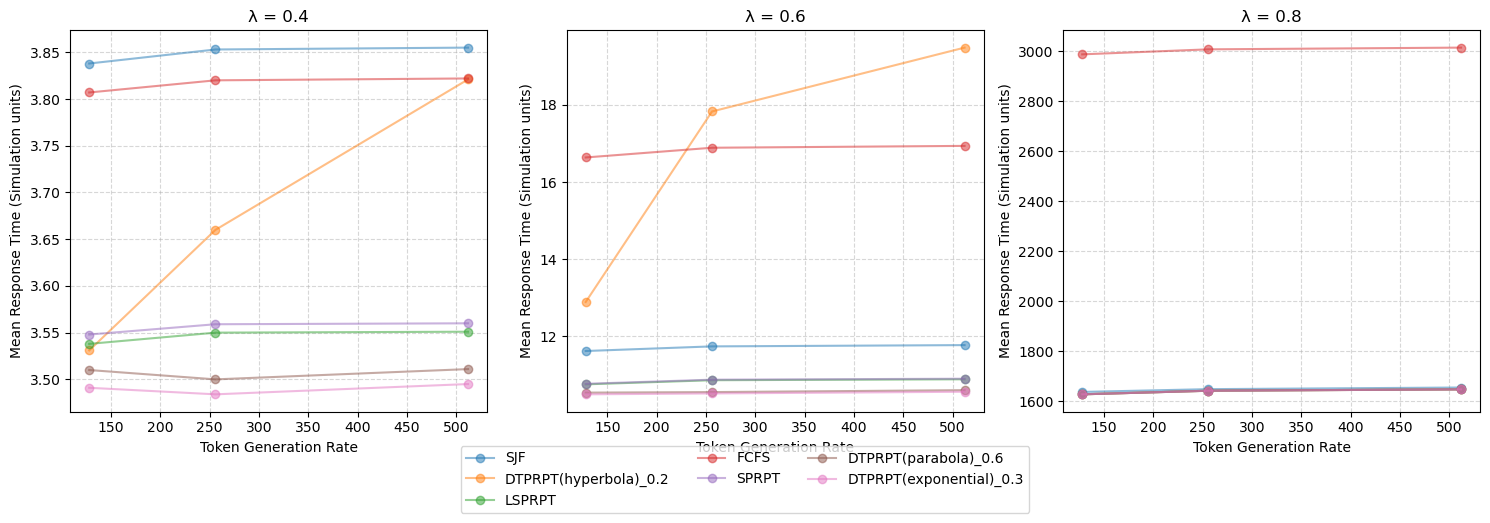

In [112]:
import pprint 
base_path = "/n/netscratch/idreos_lab/Lab/erassou/personal_scrap/MEM-PREM/paper/results/DT"
response_time_list = []
file_paths = []
for arrival_rate in [0.4, 0.6, 0.8]:
    for token_gen_rate in [128, 256, 512]:
        file_paths.append(f"{base_path}/log_arrivalrate_{arrival_rate}_tokengenrate{token_gen_rate}.txt")
response_time_triples = update_triples_from_log_list(file_paths, "Mean response time")


plot_three_subfigures(
    response_time_triples,
    xlabel="Token Generation Rate",
    ylabel="Mean Response Time (Simulation units)"
)



In [119]:
pprint.pprint(generate_latex_tables(response_time_triples))

('\\begin{table}[h]\n'
 '\\centering\n'
 '\\begin{tabular}{lccc}\n'
 '\\hline\n'
 'Policy  & 128 & 256 & 512 \\\\ \\hline\n'
 '\\hline\n'
 'DTPRPT(exponential)_0.3 & 3.491 & 3.484 & 3.495 \\\\\n'
 'DTPRPT(hyperbola)_0.2 & 3.531 & 3.660 & 3.821 \\\\\n'
 'DTPRPT(parabola)_0.6 & 3.510 & 3.500 & 3.511 \\\\\n'
 'FCFS & 3.807 & 3.820 & 3.822 \\\\\n'
 'LSPRPT & 3.538 & 3.550 & 3.551 \\\\\n'
 'SJF & 3.838 & 3.853 & 3.855 \\\\\n'
 'SPRPT & 3.548 & 3.559 & 3.560 \\\\\n'
 '\\hline\n'
 '\\end{tabular}\n'
 '\\caption{Mean response times for $\\lambda = 0.4$}\n'
 '\\end{table}\n'
 '\n'
 '\\begin{table}[h]\n'
 '\\centering\n'
 '\\begin{tabular}{lccc}\n'
 '\\hline\n'
 'Policy  & 128 & 256 & 512 \\\\ \\hline\n'
 '\\hline\n'
 'DTPRPT(exponential)_0.3 & 10.494 & 10.517 & 10.561 \\\\\n'
 'DTPRPT(hyperbola)_0.2 & 12.888 & 17.827 & 19.483 \\\\\n'
 'DTPRPT(parabola)_0.6 & 10.538 & 10.552 & 10.602 \\\\\n'
 'FCFS & 16.635 & 16.887 & 16.935 \\\\\n'
 'LSPRPT & 10.753 & 10.860 & 10.884 \\\\\n'
 'SJF & 11.617 & 11

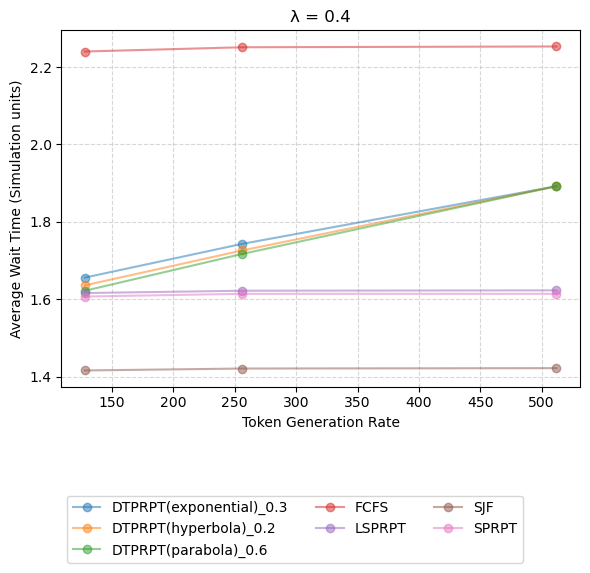

In [128]:
import pprint 
base_path = "/n/netscratch/idreos_lab/Lab/erassou/personal_scrap/MEM-PREM/paper/results/DT_soap"
file_paths = []
for arrival_rate in [0.4, 0.6, 0.8]:
    for token_gen_rate in [128, 256, 512]:
        file_paths.append(f"{base_path}/log_arrivalrate_{arrival_rate}_tokengenrate{token_gen_rate}.txt")
triple_list = update_triples_from_log_list(file_paths, "Average wait time")


plot_single_lambda(
    triple_list,
    lambda_value=0.4,
    xlabel="Token Generation Rate",
    ylabel="Average Wait Time (Simulation units)"
)

In [106]:
import pprint 
base_path = "/n/netscratch/idreos_lab/Lab/erassou/personal_scrap/MEM-PREM/paper/results/DT_soap"
file_paths = []
for arrival_rate in [0.4, 0.6, 0.8]:
    for token_gen_rate in [128, 256, 512]:
        file_paths.append(f"{base_path}/log_arrivalrate_{arrival_rate}_tokengenrate{token_gen_rate}.txt")
triple_list = update_triples_from_log_list(file_paths, "Peak memory")

print(triple_list)

# plot_three_subfigures(
#     triple_list,
#     xlabel="Token Generation Rate",
#     ylabel="Peak Memory (Tokens)"
# )

[(0.4, [128, 256, 512], {'SJF': [1698.0, 3399.0, 6800.0], 'LSPRPT': [1362.0, 2726.0, 5453.0], 'FCFS': [1189.0, 2378.0, 4757.0], 'DTPRPT(exponential)_0.3': [1189.0, 2378.0, 4757.0], 'SPRPT': [1362.0, 2726.0, 5453.0], 'DTPRPT(parabola)_0.6': [1189.0, 2378.0, 4757.0], 'DTPRPT(hyperbola)_0.2': [1189.0, 2378.0, 4757.0]}), (0.6, [128, 256, 512], {'SJF': [2514.0, 5028.0, 10056.0], 'LSPRPT': [1471.0, 2942.0, 5886.0], 'FCFS': [1189.0, 2378.0, 4757.0], 'DTPRPT(exponential)_0.3': [1281.0, 2378.0, 4757.0], 'SPRPT': [1476.0, 2952.0, 5904.0], 'DTPRPT(parabola)_0.6': [1281.0, 2378.0, 4757.0], 'DTPRPT(hyperbola)_0.2': [1281.0, 2378.0, 4757.0]}), (0.8, [128, 256, 512], {'SJF': [5153.0, 7909.0, 17417.0], 'LSPRPT': [1317.0, 2634.0, 5269.0], 'FCFS': [1189.0, 2378.0, 4757.0], 'DTPRPT(exponential)_0.3': [1317.0, 2634.0, 4757.0], 'SPRPT': [1317.0, 2634.0, 5269.0], 'DTPRPT(parabola)_0.6': [1317.0, 2634.0, 4757.0], 'DTPRPT(hyperbola)_0.2': [1317.0, 2634.0, 4757.0]})]


In [97]:
triple_list

[(0.4,
  [128, 256, 512],
  {'SJF': [1698.0, 3399.0, 6800.0],
   'LSPRPT': [1362.0, 2726.0, 5453.0],
   'FCFS': [1189.0, 2378.0, 4757.0],
   'DTPRPT(exponential)_0.3': [1189.0, 2378.0, 4757.0],
   'SPRPT': [1362.0, 2726.0, 5453.0],
   'DTPRPT(parabola)_0.6': [1189.0, 2378.0, 4757.0],
   'DTPRPT(hyperbola)_0.2': [1189.0, 2378.0, 4757.0]}),
 (0.6,
  [128, 256, 512],
  {'SJF': [2514.0, 5028.0, 10056.0],
   'LSPRPT': [1471.0, 2942.0, 5886.0],
   'FCFS': [1189.0, 2378.0, 4757.0],
   'DTPRPT(exponential)_0.3': [1281.0, 2378.0, 4757.0],
   'SPRPT': [1476.0, 2952.0, 5904.0],
   'DTPRPT(parabola)_0.6': [1281.0, 2378.0, 4757.0],
   'DTPRPT(hyperbola)_0.2': [1281.0, 2378.0, 4757.0]}),
 (0.8,
  [128, 256, 512],
  {'LSPRPT': [1317.0, 2634.0, 5269.0],
   'FCFS': [1189.0, 2378.0, 4757.0],
   'DTPRPT(exponential)_0.3': [1317.0, 2634.0, 4757.0],
   'SPRPT': [1317.0, 2634.0, 5269.0],
   'DTPRPT(parabola)_0.6': [1317.0, 2634.0, 4757.0],
   'DTPRPT(hyperbola)_0.2': [1317.0, 2634.0, 4757.0]})]

In [17]:
import matplotlib.pyplot as plt
def plot_results(results_df, metrics=None):
    """Plot comparison of policies based on selected metrics."""
    if metrics is None:
        metrics = ["completed_requests", "avg_wait_time", "mean_response_time", "avg_jct_ratio", "avg_utilization"]

    n_metrics = len(metrics)
    policies = results_df["policy"].tolist()

    # Set up the figure
    fig, axes = plt.subplots(1, n_metrics, figsize=(n_metrics * 5, 6))
    if n_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        values = results_df[metric].tolist()

        # Create bar chart
        ax.bar(policies, values)
        ax.set_ylabel(metric)
        ax.set_xticks(range(len(policies)))
        ax.set_xticklabels(policies, rotation=45, ha="right")

        # Add text labels on bars
        for j, v in enumerate(values):
            ax.text(j, v * 1.01, f"{v:}", ha="center")
    plt.tight_layout()
    plt.savefig(f"/n/netscratch/idreos_lab/Lab/erassou/personal_scrap/MEM-PREM/paper/results/policy_comparison.png")

    return fig

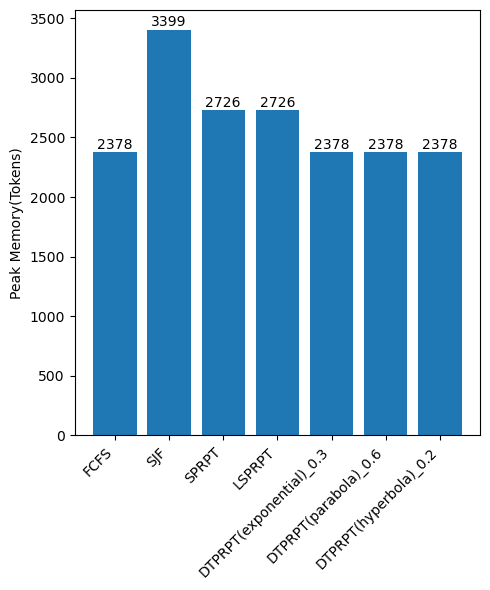

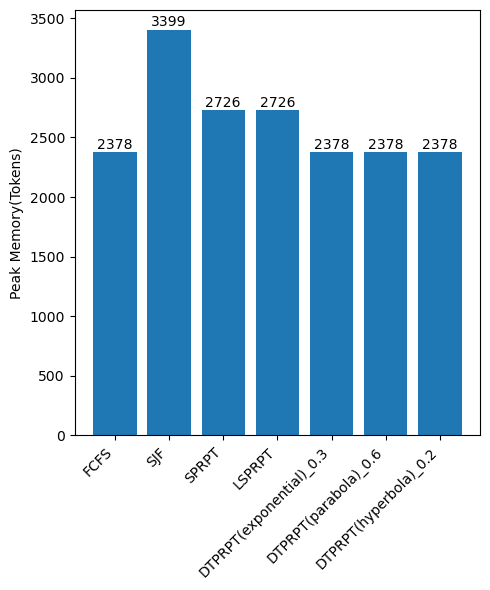

In [19]:
import pandas as pd

results_df = pd.DataFrame({
    "policy": [
        "FCFS", 
        "SJF", 
        "SPRPT", 
        "LSPRPT", 
        "DTPRPT(exponential)_0.3", 
        "DTPRPT(parabola)_0.6", 
        "DTPRPT(hyperbola)_0.2"
    ],
    # "Peak Memory(Tokens)": [2378, 3399, 2726, 2726, 2378, 2378, 3012] NOT SOAP COMPLIANT
    "Peak Memory(Tokens)": [2378, 3399, 2726, 2726, 2378, 2378, 2378] # SOAP COMPLIANT
})
plot_results(results_df, metrics=["Peak Memory(Tokens)"])